<!-- config-banner -->
# DINO 1° — building the viscosity binaries

**Reference** — builds `dino_viscAhD.bin` as `dxC * 0.27 / 2` and scales it to
the `_2p50`, `_3p00` and `_5p00` variants. `_2p00` is the 2× file the production
runs use. This is the **only recipe** for the `dino_viscAhD*.bin` files, which
are produced outside this repository and live in the untracked
`MITgcm_c69m/mysetups/DINO_1deg/input_binaries/`.

Diagnostics read the 200-year spin-up
`DINO_1deg_outputs/runs/forward/spinup_200yr_visc2x/DINO_1deg_frd_200yr_from_rest_visc2x_run30983`. It ran
`visc2x` (both `PARM05` files at `dino_viscAhD_2p00.bin`), so its `VISCAHD`
diagnostic is twice the reference field — the construction check against
`dxC * 0.27 / 2` is done on the **binary**, not on the diagnostic, and is
unaffected. Until 2026-09-03 these cells read the 1-year reference run 28402,
which was deleted in the scratch consolidation.

**Since 2026-09-09 the recipe is also a script**:
`MITgcm_c69m/mysetups/DINO_1deg/scripts/gen_viscAhD.py` rebuilds every
`dino_viscAhD*.bin` from `input_binaries/tile001.mitgrid` and reproduces the
existing files **byte for byte** (`--check`). The construction below is DINO's
own law — NEMO `nn_ahm_ijk_t = 20`, A_h = ½·U_v·Δx with `rn_Uv = 0.27` m/s in
the DINO `namelist_cfg` — and the reason the field stays a `PARM05` file is
that MITgcm has no parameter linear in Δx (`viscAhGrid` is ∝ L²/Δt, which is
what the retired comparison below measured); see the setup README, "Lateral
viscosity and vertical diffusivity: file or parameter", and
`diffkr_as_parameter_validation_from170yrPk_visc2x.ipynb` beside this one.
One detail the `max|diff| = 0` result hides: the original files were computed
in **float32** from the model's float32 `DXC` output, so the float64 route
(`dxC` from the grid file at full precision) differs by one float32 ulp, up to
1.6e-3 m²/s; the script casts to float32 first, as the original did.


## Retired: the three `viscAhGrid` comparison notebooks (2026-09-03)

`01_viscRef_vs_viscGrid1p0e-2`, `02_viscGrid1p135e-2_increased` and
`03_viscGrid9p0e-3_decreased` sat beside this notebook and compared the
`PARM05` file-based viscosity (run 28402) against `PARM01`'s scalar
`viscAhGrid` at three values. All four runs were deleted in the scratch
consolidation, so they are retired to
`~/trash/Proj_ImPACTS/analyses/DINO_1deg/02_forward/01_viscosity_study/`. Their
result, at the last `viscDiag` record of each 1-year run:

| Setting | Run | Domain-mean `VISCAHD` | Mid-Y (`j=98`) mean `VISCAHD` |
| --- | --- | --- | --- |
| `PARM05` files, reference (`dino_viscAhD.bin`) | 28402 | 10591.9 | 15011.9 |
| `viscAhGrid = 9.0E-3` | 28451 | 8397.9 | 15456.5 |
| `viscAhGrid = 1.0E-2` | 28447 | 9331.0 | 17173.9 |
| `viscAhGrid = 1.135E-2` | 28448 | 10590.7 | 19492.4 |

**What that says.** `viscAhGrid = 1.135E-2` is the value that reproduces the
reference field's *domain mean* — 10590.7 against 10591.9, a difference of 1.2
(0.01 %). It does **not** reproduce the field: at mid-domain the grid-based
viscosity is 19492 against the reference's 15012, 30 % high, because
`viscAhGrid` scales with the local grid spacing squared over the time step
while `dxC * 0.27 / 2` is linear in `dxC`. Matching the mean therefore buys
nothing structurally, which is why the production runs use the `PARM05` files.

In all three runs `VISCAHD` and `VISCAHZ` agree to ~0.1 or better, i.e. the
`viscAhGrid` path sets both components equally, exactly as passing the same
file to `viscAhDfile` and `viscAhZfile` does.

The construction check below is the part worth keeping: `dino_viscAhD.bin`
reproduces `dxC * 0.27 / 2` **exactly** — `max|diff| = 0.0`, `rms = 0.0`.


In [2]:
import numpy as np
import xarray as xr
from pathlib import Path
import glob
import xmitgcm

import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

In [3]:
# -------------------------------
# User inputs
# -------------------------------
run_dir = Path("/scratch2/tshahriar/DINO_1deg_outputs/runs/forward/spinup_200yr_visc2x/DINO_1deg_frd_200yr_from_rest_visc2x_run30983/")

grid_dir = run_dir  # change if your grid files live elsewhere
bin_dir = Path("/home/tshahriar/Proj_ImPACTS/impacts-mitgcm/MITgcm_c69m/mysetups/DINO_1deg/input_binaries")  # <-- adjust if needed
bin_file = bin_dir / "dino_viscAhD.bin"

ref = np.datetime64("2000-01-01T00:00:00")
delta_t = 1800.0

In [4]:
# --- grid sizes (from SIZE.h) ---
Nx, Ny, Nr = 51, 198, 36

# --- read MITgcm binary (big-endian float64) ---
# MITgcm writes in Fortran order with i (x) fastest.
data = np.fromfile(bin_file, dtype=">f8")  # big-endian float64

expected = Nx * Ny * Nr
assert data.size == expected, f"Unexpected size: got {data.size}, expected {expected}"

viscAhD = data.reshape((Nx, Ny, Nr), order="F")  # shape (x, y, z)

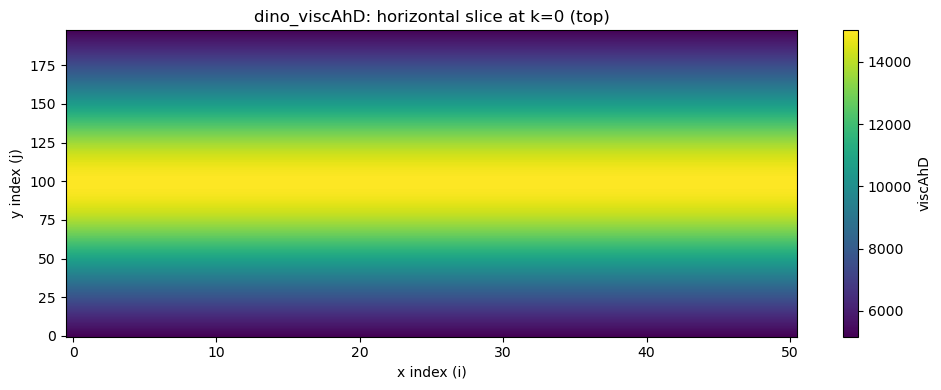

In [5]:
# ----------------------------
# 1) Horizontal map at a level
# ----------------------------
k = 0  # 0=top level
field_xy = viscAhD[:, :, k].T  # transpose to (y, x) for plotting

plt.figure(figsize=(10, 4))
plt.imshow(field_xy, origin="lower", aspect="auto")
plt.colorbar(label="viscAhD")
plt.title(f"dino_viscAhD: horizontal slice at k={k} (top)")
plt.xlabel("x index (i)")
plt.ylabel("y index (j)")
plt.tight_layout()
plt.show()

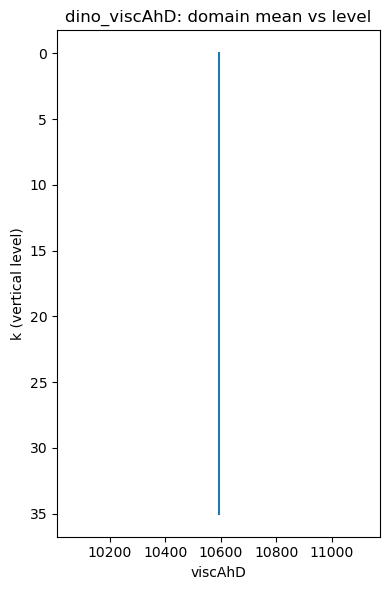

In [6]:
# --------------------------------------
# 2) Zonal mean profile (mean over x,y)
# --------------------------------------
profile = viscAhD.mean(axis=(0, 1))  # shape (Nr,)

plt.figure(figsize=(4, 6))
plt.plot(profile, np.arange(Nr))
plt.gca().invert_yaxis()
plt.title("dino_viscAhD: domain mean vs level")
plt.xlabel("viscAhD")
plt.ylabel("k (vertical level)")
plt.tight_layout()
plt.show()

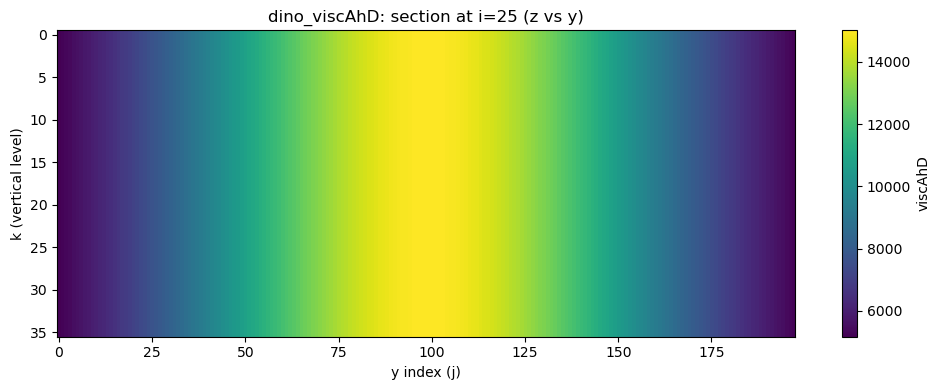

In [7]:
# --------------------------------------
# 3) Meridional section at a given x index
# --------------------------------------
i0 = Nx // 2
section_yz = viscAhD[i0, :, :].T  # (z, y)

plt.figure(figsize=(10, 4))
plt.imshow(section_yz, origin="upper", aspect="auto")
plt.colorbar(label="viscAhD")
plt.title(f"dino_viscAhD: section at i={i0} (z vs y)")
plt.xlabel("y index (j)")
plt.ylabel("k (vertical level)")
plt.tight_layout()
plt.show()

In [8]:
# iters = sorted([int(p.name.split(".")[-2]) for p in run_dir.glob("viscDiag.*.meta")])
# # iters

In [9]:
# iters[-1]

In [10]:
# -----------------------
# 1) Load ONE viscDiag timestep with xmitgcm
# -----------------------
iters = sorted([int(p.name.split(".")[-2]) for p in run_dir.glob("viscDiag.*.meta")])
it = iters[-1]  # last available
ds = xmitgcm.open_mdsdataset(
    data_dir=str(run_dir),
    grid_dir=str(grid_dir),
    prefix=["viscDiag"],
    geometry="curvilinear",
    iters=[it],
    delta_t=delta_t,
    ref_date=ref,
)

In [11]:
ds

<xarray.Dataset>
Dimensions:  (i: 51, i_g: 51, j: 198, j_g: 198, k: 36, k_u: 36, k_l: 36,
              k_p1: 37, time: 1)
Coordinates: (12/44)
  * i        (i) int64 0 1 2 3 4 5 6 7 8 9 10 ... 41 42 43 44 45 46 47 48 49 50
  * i_g      (i_g) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 189 190 191 192 193 194 195 196 197
  * j_g      (j_g) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * k        (k) int64 0 1 2 3 4 5 6 7 8 9 10 ... 26 27 28 29 30 31 32 33 34 35
  * k_u      (k_u) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
    ...       ...
    maskS    (k, j_g, i) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    rhoRef   (k) >f4 1.024e+03 1.024e+03 1.024e+03 ... 1.045e+03 1.048e+03
    dxF      (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF      (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV      (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU      (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    VISCAHZ  (time, k, j_g, i_g) >f4 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    VISCAHD  (time, k, j, i) >f4 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [14]:
ds.VISCAHD.shape

(1, 36, 198, 51)

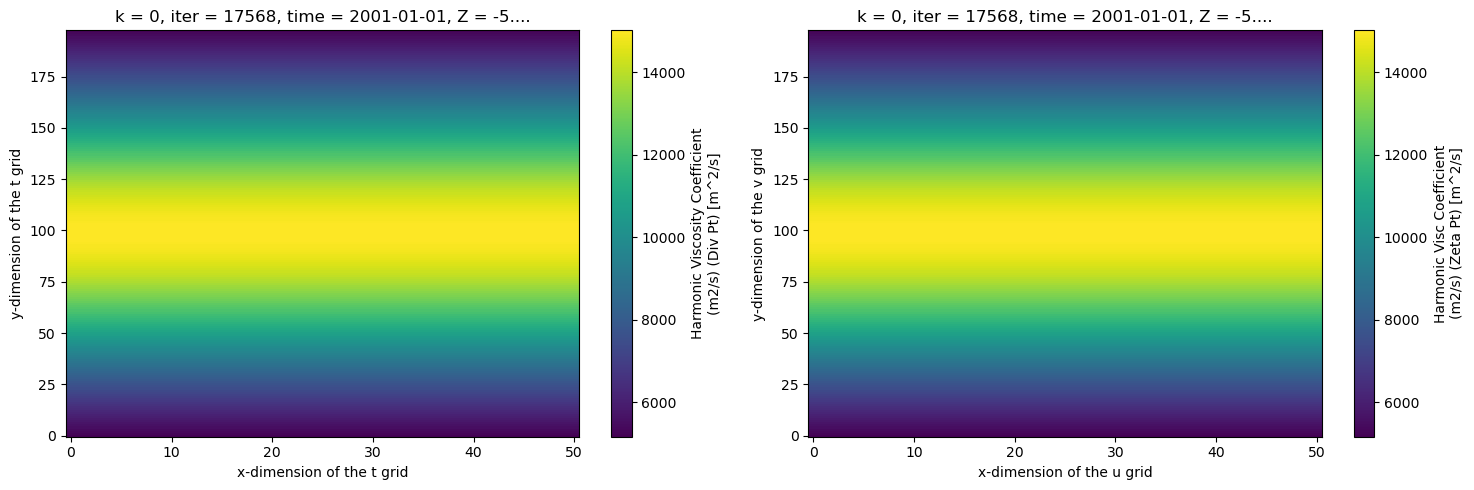

In [15]:
vmin = min(ds.VISCAHD[0,0].min().compute(), ds.VISCAHZ[0,0].min().compute())
vmax = max(ds.VISCAHD[0,0].max().compute(), ds.VISCAHZ[0,0].max().compute())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ds.VISCAHD[0,0].plot(ax=ax[0], vmin=vmin, vmax=vmax)
ds.VISCAHZ[0,0].plot(ax=ax[1], vmin=vmin, vmax=vmax)

plt.tight_layout()
plt.show()

In [16]:
m1 = ds.VISCAHD[0,0].mean().compute().item()
m2 = ds.VISCAHZ[0,0].mean().compute().item()
md = (ds.VISCAHD[0,0] - ds.VISCAHZ[0,0]).mean().compute().item()

print(f"Domain mean VISCAHD        = {m1}")
print(f"Domain mean VISCAHZ        = {m2}")
print(f"Mean difference (D - Z)    = {md}")

Domain mean VISCAHD        = 10591.8896484375
Domain mean VISCAHZ        = 10591.8896484375
Mean difference (D - Z)    = -0.0005038364324718714


In [17]:
U_char = 0.27
# -----------------------------
# 1) Build "expected" viscAhD from dxC * 0.27 / 2  (2D -> 3D)
# -----------------------------
# dxC is (j,i). Your binary is (i,j,k). We'll make computed_visc (i,j,k).
dxC_ji = ds["dxC"].values                  # (Ny, Nx)
visc2d_ji = dxC_ji * U_char / 2.0          # (Ny, Nx)

In [18]:
visc2d_ji.shape

(198, 51)

In [19]:
# Convert to (i,j) to match your binary array ordering
visc2d_ij = visc2d_ji.T                    # (Nx, Ny)
visc2d_ij.shape

(51, 198)

In [20]:
# Broadcast to 3D (i,j,k) because dino_viscAhD.bin is 3D but constant in k
visc_from_dxC = np.repeat(visc2d_ij[:, :, None], Nr, axis=2)  # (Nx, Ny, Nr)
visc_from_dxC.shape

(51, 198, 36)

In [21]:
visc_from_dxC[0].shape

(198, 36)

In [22]:
# -----------------------------
# 2) Compare computed vs binary
# -----------------------------
diff_bin = viscAhD - visc_from_dxC
print("dxC*0.27/2  vs  dino_viscAhD.bin")
print("  max|diff| =", np.nanmax(np.abs(diff_bin)))
print("  rms(diff) =", np.sqrt(np.nanmean(diff_bin**2)))
print("  rel max   =", np.nanmax(np.abs(diff_bin)) / np.nanmax(np.abs(viscAhD)))


dxC*0.27/2  vs  dino_viscAhD.bin
  max|diff| = 0.0
  rms(diff) = 0.0
  rel max   = 0.0


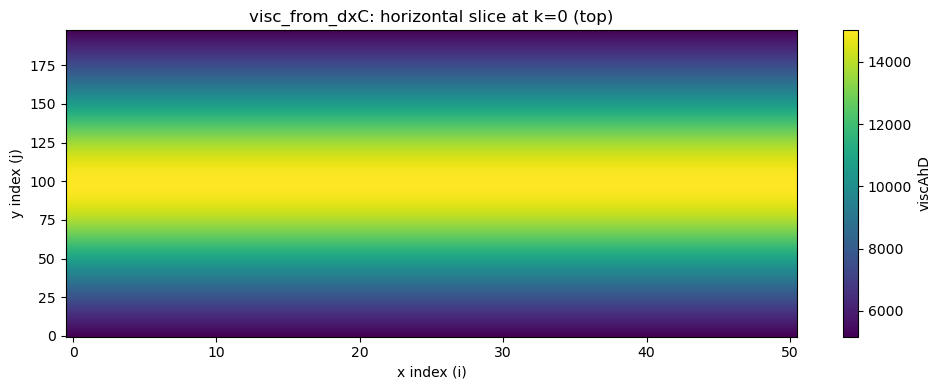

In [24]:
# ----------------------------
# 1) Horizontal map at a level
# ----------------------------
k = 0  # 0=top level
field_xy = visc_from_dxC[:, :, k].T  # transpose to (y, x) for plotting

plt.figure(figsize=(10, 4))
plt.imshow(field_xy, origin="lower", aspect="auto")
plt.colorbar(label="viscAhD")
plt.title(f"visc_from_dxC: horizontal slice at k={k} (top)")
plt.xlabel("x index (i)")
plt.ylabel("y index (j)")
plt.tight_layout()
plt.show()


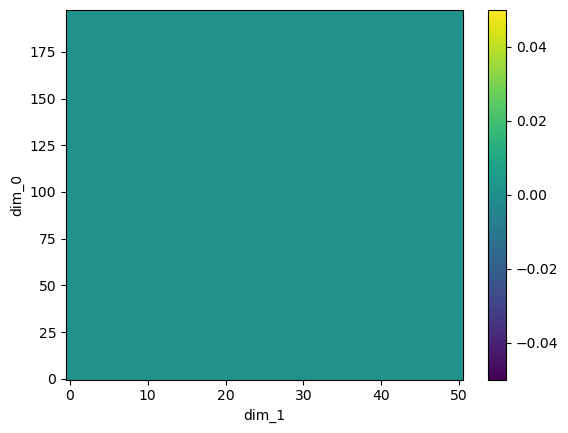

In [25]:
xr.DataArray(visc_from_dxC[:, :, 0].T - viscAhD[:, :, 0].T).plot()

In [26]:
m1 = visc_from_dxC[:, :, 0].T.mean()
m2 = viscAhD[:, :, 0].T.mean()

print("Mean (visc_from_dxC) =", m1)
print("Mean (viscAhD)       =", m2)
print("Difference           =", m1 - m2)

Mean (visc_from_dxC) = 10591.889
Mean (viscAhD)       = 10591.88971255524
Difference           = -0.0010406802393845282


In [ ]:
# bin_dir  = Path("/home/tshahriar/Proj_ImPACTS/impacts-mitgcm/MITgcm_c69m/mysetups/DINO_1deg/input_binaries")
# src      = bin_dir / "dino_viscAhD.bin"
# # out_90   = bin_dir / "dino_viscAhD_0p90.bin"
# # out_110  = bin_dir / "dino_viscAhD_1p10.bin"
# # out_150  = bin_dir / "dino_viscAhD_1p50.bin"
# # out_200  = bin_dir / "dino_viscAhD_2p00.bin"

# out_250  = bin_dir / "dino_viscAhD_2p50.bin"
# out_300  = bin_dir / "dino_viscAhD_3p00.bin"
# out_500  = bin_dir / "dino_viscAhD_5p00.bin"

# Nx, Ny, Nr = 51, 198, 36

# # Read (big-endian float64)
# a = np.fromfile(src, dtype=">f8")
# assert a.size == Nx*Ny*Nr

# # Scale

# a250 = a * 2.50
# a300 = a * 3.00
# a500 = a * 5.00

# # Write back in same dtype/endianness
# a250.astype(">f8").tofile(out_250)
# a300.astype(">f8").tofile(out_300)
# a500.astype(">f8").tofile(out_500)

# print("Wrote:", out_250)
# print("Wrote:", out_300)
# print("Wrote:", out_500)

In [ ]:
# print(src.stat().st_size) # If 2908224 is printed, then it is float